<a href="https://colab.research.google.com/github/firatsayici/derinogrenme/blob/main/face_mask_detection_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Face Mask Detection with MobileNetV2 (TensorFlow/Keras)


In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc


In [5]:
import os
from PIL import Image
import numpy as np
import shutil # Import shutil for rmtree

# Veri yolu
data_dir = 'data'

# Remove existing data directory to ensure a fresh start for dummy data generation
if os.path.exists(data_dir):
    print(f"'{data_dir}' dizini zaten mevcut. Yeniden oluşturmak için siliniyor...")
    shutil.rmtree(data_dir)
    print(f"'{data_dir}' dizini başarıyla silindi.")

print(f"'{data_dir}' dizini bulunamadı. Demo amacıyla sahte veri dizinleri ve resimler oluşturuluyor.")
os.makedirs(os.path.join(data_dir, 'with_mask'), exist_ok=True)
os.makedirs(os.path.join(data_dir, 'without_mask'), exist_ok=True)

# Function to create a simple dummy image
def create_dummy_image(filepath, size=(224, 224)):
    img = Image.fromarray(np.random.randint(0, 255, size=(size[0], size[1], 3), dtype=np.uint8))
    img.save(filepath)

# Create more dummy images to ensure validation split has data
num_dummy_images_per_class = 5 # Changed from 2 to 5 to make validation set non-empty
for i in range(num_dummy_images_per_class):
    create_dummy_image(os.path.join(data_dir, 'with_mask', f'dummy_mask_{i+1}.png'))
    create_dummy_image(os.path.join(data_dir, 'without_mask', f'dummy_nomask_{i+1}.png'))
print(f"Sahte 'data' dizini, alt dizinler ve her sınıf için {num_dummy_images_per_class} adet sahte resim başarıyla oluşturuldu.")

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

'data' dizini zaten mevcut. Yeniden oluşturmak için siliniyor...
'data' dizini başarıyla silindi.
'data' dizini bulunamadı. Demo amacıyla sahte veri dizinleri ve resimler oluşturuluyor.
Sahte 'data' dizini, alt dizinler ve her sınıf için 5 adet sahte resim başarıyla oluşturuldu.
Found 8 images belonging to 2 classes.
Found 2 images belonging to 2 classes.
Found 10 images belonging to 2 classes.


In [6]:
# Model
base_model = MobileNetV2(input_shape=(224,224,3), include_top=False, weights='imagenet')
base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
output = layers.Dense(train_generator.num_classes, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
# Eğitim
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100
)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7500 - loss: 0.6243 - val_accuracy: 0.5000 - val_loss: 0.7419
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 764ms/step - accuracy: 0.7500 - loss: 0.6002 - val_accuracy: 0.0000e+00 - val_loss: 1.2258
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 557ms/step - accuracy: 0.2500 - loss: 1.0459 - val_accuracy: 0.5000 - val_loss: 0.8233
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 576ms/step - accuracy: 0.5000 - loss: 0.9237 - val_accuracy: 0.5000 - val_loss: 0.6458
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 977ms/step - accuracy: 0.5000 - loss: 0.7713 - val_accuracy: 0.0000e+00 - val_loss: 0.9341
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.4390 - val_accuracy: 0.0000e+00 - val_loss: 1.3007
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7500 - loss: 0.5623 - val_accuracy: 0.5000 - val_loss: 0.7780
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 792ms/step - accuracy: 0.7500 - loss: 0.6992 - val_accuracy: 0.5000 

In [11]:
# Tahmin
pred_probs = model.predict(test_generator)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_generator.classes

accuracy = np.mean(y_pred == y_true)
print('Accuracy:', accuracy)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step
Accuracy: 0.8


[[5 0]
 [2 3]]


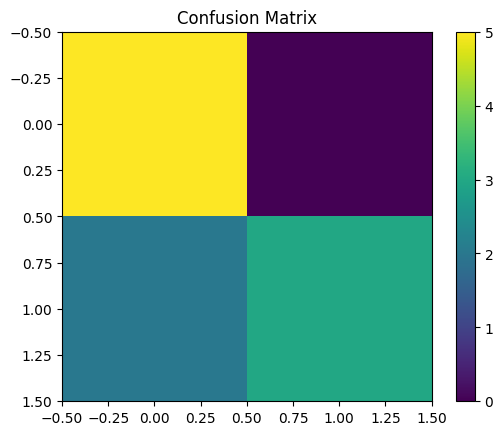

In [12]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print(cm)

plt.imshow(cm)
plt.title('Confusion Matrix')
plt.colorbar()
plt.show()


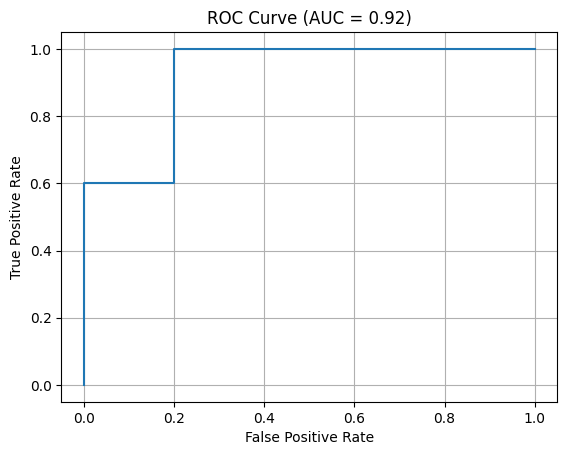

In [13]:
# ROC Curve (binary)
if train_generator.num_classes == 2:
    fpr, tpr, _ = roc_curve(y_true, pred_probs[:,1])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.grid()
    plt.show()


In [14]:
# Precision, Recall, F1
report = classification_report(y_true, y_pred, target_names=list(train_generator.class_indices.keys()))
print(report)


              precision    recall  f1-score   support

   with_mask       0.71      1.00      0.83         5
without_mask       1.00      0.60      0.75         5

    accuracy                           0.80        10
   macro avg       0.86      0.80      0.79        10
weighted avg       0.86      0.80      0.79        10

